<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 100%); color: white; padding: 40px; margin: -10px -10px 20px -10px; border-radius: 0 0 15px 15px;">
<h1 style="margin: 0; font-size: 2.5em;">Applications: Superconducting AI Accelerators</h1>
<p style="margin: 10px 0 0 0; font-size: 1.2em; opacity: 0.9;">Week 4, Session 1 — SCE Futures</p>
</div>

## Contents

1. [The AI Compute Problem](#1-ai-compute-problem)
2. [Why Superconducting Logic for AI?](#2-why-sce)
3. [AQFP for Neural Networks](#3-aqfp-neural-networks)
4. [Memory Architecture Challenge](#4-memory)
5. [System Architecture](#5-system-architecture)
6. [Current Research](#6-current-research)
7. [Quantized Networks](#7-quantized-networks)
8. [Challenges and Path Forward](#8-challenges)
9. [Other SCE Applications](#9-other-applications)

In [1]:
# Setup: Import libraries for visualizations
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import FancyBboxPatch, Rectangle, Circle, FancyArrowPatch
import numpy as np

# Color scheme
COLORS = {
    'primary': '#2196F3',
    'secondary': '#FF9800',
    'success': '#4CAF50',
    'danger': '#f44336',
    'dark': '#1a1a2e',
    'light': '#f5f5f5',
    'superconducting': '#00BCD4',
    'normal': '#9E9E9E',
    'purple': '#9C27B0',
    'teal': '#009688'
}

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['font.size'] = 11

print("Setup complete.")

Setup complete.


---
<a id="1-ai-compute-problem"></a>
# 1. The AI Compute Problem
---

AI compute demand is growing at an unprecedented rate, far exceeding the historical Moore's Law pace (which has now stalled) and pushing against fundamental power limits.

### Exponential Growth in Training Compute

The compute required to train frontier AI models has been **doubling every ~6 months** (approximately 4x per year):

| Model | Year | Training Compute (FLOPs) |
|-------|------|-------------------------|
| AlexNet | 2012 | ~10^17 |
| GPT-2 | 2019 | ~10^21 |
| GPT-3 | 2020 | ~10^23 |
| GPT-4 | 2023 | ~10^25 |
| Future frontier | 2025+ | 10^26 - 10^27 |

This represents a **10 billion-fold increase** in compute requirements over just 11 years.

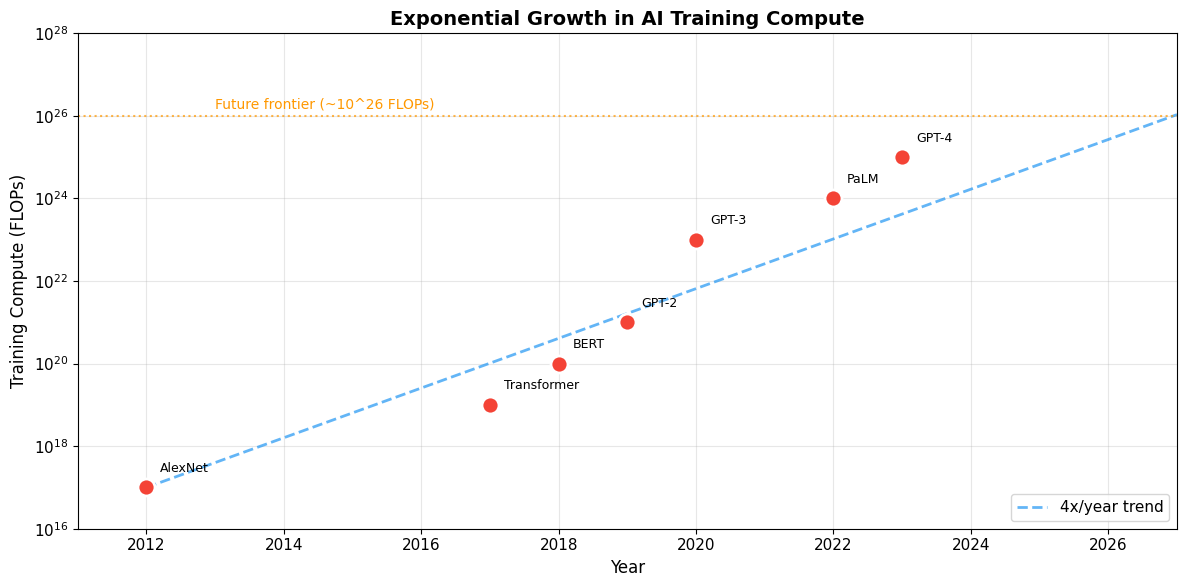

Key insight: AI compute requirements are doubling every ~6 months (4x per year).
Moore's Law (doubling every ~18 months) has essentially stalled since ~2015.


In [2]:
# Visualize: AI compute growth over time
fig, ax = plt.subplots(figsize=(12, 6))

# Data points for major models
models = [
    (2012, 1e17, 'AlexNet'),
    (2017, 1e19, 'Transformer'),
    (2018, 1e20, 'BERT'),
    (2019, 1e21, 'GPT-2'),
    (2020, 1e23, 'GPT-3'),
    (2022, 1e24, 'PaLM'),
    (2023, 1e25, 'GPT-4'),
]

years = [m[0] for m in models]
flops = [m[1] for m in models]
names = [m[2] for m in models]

# Plot actual models
ax.scatter(years, flops, s=150, color=COLORS['danger'], zorder=5, edgecolor='white', linewidth=2)

# Extrapolation line (doubling every 6 months = 4x per year)
years_ext = np.linspace(2012, 2027, 100)
flops_trend = 1e17 * (4 ** (years_ext - 2012))
ax.plot(years_ext, flops_trend, '--', color=COLORS['primary'], alpha=0.7, linewidth=2, label='4x/year trend')

# Annotations
for year, flop, name in models:
    offset = (0.2, 1.5) if name not in ['BERT', 'Transformer'] else (0.2, 0.3)
    ax.annotate(name, (year, flop), xytext=(year + 0.2, flop * 2), fontsize=9,
                ha='left', va='bottom')

# Future projections
ax.axhline(y=1e26, color=COLORS['secondary'], linestyle=':', alpha=0.7)
ax.text(2013, 1.5e26, 'Future frontier (~10^26 FLOPs)', fontsize=10, color=COLORS['secondary'])

ax.set_yscale('log')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Training Compute (FLOPs)', fontsize=12)
ax.set_title('Exponential Growth in AI Training Compute', fontsize=14, fontweight='bold')
ax.set_xlim(2011, 2027)
ax.set_ylim(1e16, 1e28)
ax.grid(True, alpha=0.3, which='both')
ax.legend(loc='lower right')

plt.tight_layout()
plt.show()

print("Key insight: AI compute requirements are doubling every ~6 months (4x per year).")
print("Moore's Law (doubling every ~18 months) has essentially stalled since ~2015.")

### The Power Wall

This exponential growth in compute translates directly to power consumption:

| System | Power | Compute Capability |
|--------|-------|--------------------|
| Single H100 GPU | 700 W | 2 PFLOPS (FP16) |
| H100 DGX system (8 GPUs) | ~10 kW | 16 PFLOPS |
| 10k GPU training cluster | **7 MW** | 20 EFLOPS |
| Large hyperscale DC | 100-500 MW | ~100 EFLOPS |
| Largest DCs today | **1+ GW** | ~1 ZFLOP |

### The Numbers in Context

- **7 MW** = power consumption of a small town (~5,000 homes)
- **1 GW** = output of a nuclear reactor (datacenters are already at this scale)
- Training one frontier model: **$100M+ in electricity alone**
- Global data center power: ~1-2% of world electricity (and growing)

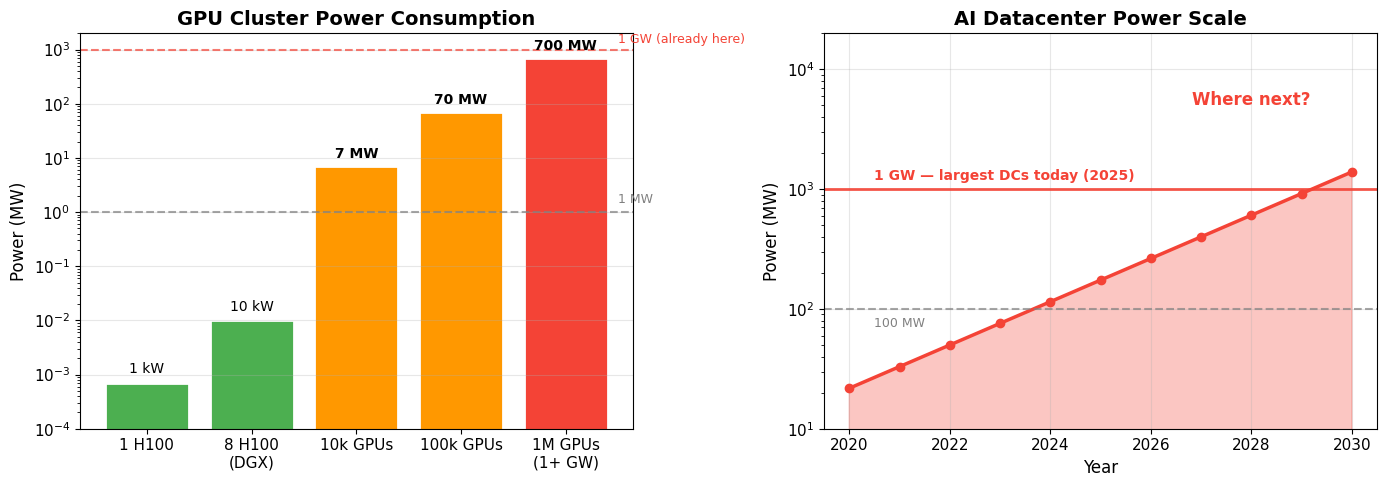

Largest datacenters today are already at 1+ GW scale.
Continued scaling requires fundamental improvements in compute efficiency.


In [3]:
# Visualize: Power consumption at scale
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: Power by system size
systems = ['1 H100', '8 H100\n(DGX)', '10k GPUs', '100k GPUs', '1M GPUs\n(1+ GW)']
power_mw = [0.0007, 0.01, 7, 70, 700]
colors = [COLORS['success'] if p < 1 else COLORS['secondary'] if p < 100 else COLORS['danger'] for p in power_mw]

bars = ax1.bar(systems, power_mw, color=colors, edgecolor='white', linewidth=2)
ax1.set_ylabel('Power (MW)', fontsize=12)
ax1.set_title('GPU Cluster Power Consumption', fontsize=14, fontweight='bold')
ax1.set_yscale('log')
ax1.set_ylim(0.0001, 2000)
ax1.grid(True, alpha=0.3, axis='y')

# Reference lines
ax1.axhline(y=1, color='gray', linestyle='--', alpha=0.7)
ax1.text(4.5, 1.5, '1 MW', fontsize=9, color='gray')
ax1.axhline(y=1000, color=COLORS['danger'], linestyle='--', alpha=0.7)
ax1.text(4.5, 1300, '1 GW (already here)', fontsize=9, color=COLORS['danger'])

# Annotate values
for bar, pwr in zip(bars, power_mw):
    if pwr >= 1:
        label = f'{pwr:.0f} MW' if pwr < 1000 else f'{pwr/1000:.1f} GW'
        ax1.text(bar.get_x() + bar.get_width()/2, pwr * 1.4, label,
                ha='center', fontsize=10, fontweight='bold')
    else:
        ax1.text(bar.get_x() + bar.get_width()/2, pwr * 1.5, f'{pwr*1000:.0f} kW',
                ha='center', fontsize=10)

# Right: Current state and trajectory
years = np.arange(2020, 2031)
# Power trajectory - we're already at 1 GW in 2025
power_trajectory = 50 * (2 ** ((years - 2022) * 0.6))

ax2.fill_between(years, power_trajectory, alpha=0.3, color=COLORS['danger'])
ax2.plot(years, power_trajectory, color=COLORS['danger'], linewidth=2.5, marker='o', markersize=6)

# Mark current scale
ax2.axhline(y=1000, color=COLORS['danger'], linestyle='-', alpha=0.9, linewidth=2)
ax2.text(2020.5, 1200, '1 GW — largest DCs today (2025)', fontsize=10, color=COLORS['danger'], fontweight='bold')

ax2.axhline(y=100, color='gray', linestyle='--', alpha=0.7)
ax2.text(2020.5, 70, '100 MW', fontsize=9, color='gray')

ax2.set_xlabel('Year', fontsize=12)
ax2.set_ylabel('Power (MW)', fontsize=12)
ax2.set_title('AI Datacenter Power Scale', fontsize=14, fontweight='bold')
ax2.set_yscale('log')
ax2.set_ylim(10, 20000)
ax2.set_xlim(2019.5, 2030.5)
ax2.grid(True, alpha=0.3)

ax2.annotate('Where next?', xy=(2028, 5000), fontsize=12,
            color=COLORS['danger'], fontweight='bold', ha='center')

plt.tight_layout()
plt.show()

print("Largest datacenters today are already at 1+ GW scale.")
print("Continued scaling requires fundamental improvements in compute efficiency.")

### Why This Matters

The **power wall** is the key constraint on AI progress:

1. **Physical limits**: 1+ GW data centers are already being built, but scaling further is challenging
2. **Grid constraints**: Not enough power infrastructure in most locations
3. **Environmental impact**: Carbon footprint of AI training is significant
4. **Economic limits**: Electricity costs dominate training budgets

**Superconducting electronics offers a path through this wall.**

---
<a id="2-why-sce"></a>
# 2. Why Superconducting Logic for AI?
---

Superconducting logic, particularly **AQFP (Adiabatic Quantum-Flux-Parametron)**, offers dramatic improvements in energy efficiency.

### Energy Efficiency Comparison

| Technology | Energy per Operation | Notes |
|------------|---------------------|-------|
| CMOS 28nm | ~35,000 aJ | Older node |
| CMOS 7nm | ~13,000 aJ | Current high-performance |
| CMOS 3nm | ~140 aJ | Latest node |
| RSFQ | ~100 aJ | High-speed SCE |
| ERSFQ | ~10 aJ | Energy-efficient SFQ |
| **AQFP** | **~1.4 zJ** | Ultra-low power SCE |

**AQFP is ~100,000× more efficient than CMOS 3nm per operation.**

But wait - don't we need to account for cooling overhead?

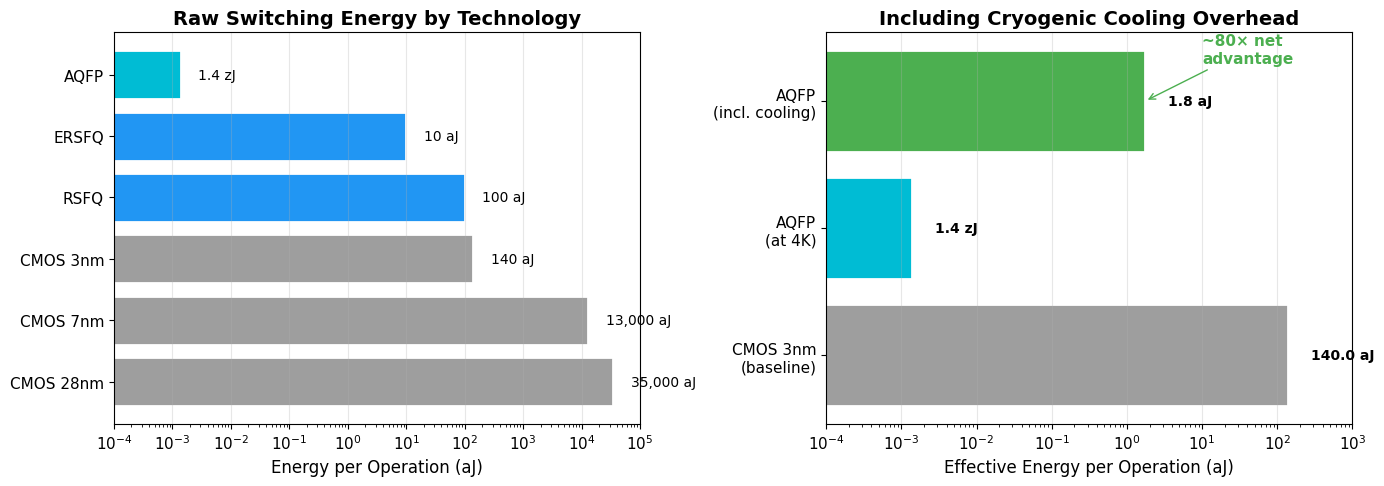

In [4]:
# Visualize: Energy efficiency comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: Raw energy per operation
technologies = ['CMOS 28nm', 'CMOS 7nm', 'CMOS 3nm', 'RSFQ', 'ERSFQ', 'AQFP']
energies = [35000, 13000, 140, 100, 10, 0.0014]  # in attojoules (aJ); AQFP = 1.4 zJ = 0.0014 aJ
colors = [COLORS['normal'], COLORS['normal'], COLORS['normal'], 
          COLORS['primary'], COLORS['primary'], COLORS['superconducting']]

bars = ax1.barh(technologies, energies, color=colors, edgecolor='white', linewidth=2)
ax1.set_xscale('log')
ax1.set_xlabel('Energy per Operation (aJ)', fontsize=12)
ax1.set_title('Raw Switching Energy by Technology', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='x')
ax1.set_xlim(0.0001, 100000)

# Annotate values
for bar, energy in zip(bars, energies):
    if energy < 1:
        label = f'{energy*1000:.1f} zJ'
    else:
        label = f'{energy:,.0f} aJ'
    ax1.text(energy * 2, bar.get_y() + bar.get_height()/2, 
            label, va='center', fontsize=10)

# Right: Including cooling overhead
techs_net = ['CMOS 3nm\n(baseline)', 'AQFP\n(at 4K)', 'AQFP\n(incl. cooling)']
energies_net = [140, 0.0014, 140/80]  # ~1.75 aJ effective
colors_net = [COLORS['normal'], COLORS['superconducting'], COLORS['success']]

bars2 = ax2.barh(techs_net, energies_net, color=colors_net, edgecolor='white', linewidth=2)
ax2.set_xscale('log')
ax2.set_xlabel('Effective Energy per Operation (aJ)', fontsize=12)
ax2.set_title('Including Cryogenic Cooling Overhead', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='x')
ax2.set_xlim(0.0001, 1000)

for bar, energy in zip(bars2, energies_net):
    if energy < 1:
        label = f'{energy*1000:.1f} zJ'
    else:
        label = f'{energy:.1f} aJ'
    ax2.text(energy * 2, bar.get_y() + bar.get_height()/2, 
            label, va='center', fontsize=10, fontweight='bold')

# Add annotation
ax2.annotate('~80× net\nadvantage', xy=(140/80, 2), xytext=(10, 2.3),
            fontsize=11, color=COLORS['success'], fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=COLORS['success']))

plt.tight_layout()
plt.show()

### Cryogenic Cooling Overhead Analysis

The key question: **Does the energy savings outweigh the cooling cost?**

#### Carnot Efficiency

The theoretical minimum work to remove 1 W of heat from 4K to 300K:

$$W_{min} = Q \cdot \frac{T_{hot} - T_{cold}}{T_{cold}} = 1W \cdot \frac{300-4}{4} = 74 W$$

#### Practical Cryocoolers

Real cryocoolers operate at 10-15% of Carnot efficiency:

| Cryocooler Type | Efficiency | Power at 300K per 1W at 4K |
|-----------------|------------|---------------------------|
| Gifford-McMahon | ~5-10% | ~1000-1500 W |
| Pulse Tube | ~10-15% | ~500-750 W |
| Advanced systems | ~15% | ~500 W |

**Rule of thumb: ~1000 W at room temperature per 1 W removed at 4K**

#### Break-Even Analysis

For superconducting logic to win:

$$\frac{E_{CMOS}}{E_{SCE}} > \text{Cooling overhead}$$

$$\frac{13,000 \text{ aJ}}{1.4 \text{ aJ}} \approx 9,300 > 1,000 \checkmark$$

**AQFP achieves ~80x net advantage even with cooling overhead for compute-bound workloads.**

In [5]:
# Cryogenic cooling analysis
print("Cryogenic Cooling Analysis")
print("=" * 50)

# Parameters
T_cold = 4.2  # K (liquid helium temperature)
T_hot = 300   # K (room temperature)

# Carnot limit
carnot_cop = T_cold / (T_hot - T_cold)
carnot_power = 1 / carnot_cop  # W at 300K per W at 4K

print(f"\nCarnot limit:")
print(f"  COP = T_cold / (T_hot - T_cold) = {T_cold} / ({T_hot} - {T_cold}) = {carnot_cop:.4f}")
print(f"  Minimum work: {carnot_power:.1f} W at 300K per 1W removed at 4K")

# Practical efficiency
practical_efficiency = 0.12  # 12% of Carnot
practical_power = carnot_power / practical_efficiency

print(f"\nPractical cryocoolers (~12% of Carnot):")
print(f"  Work required: {practical_power:.0f} W at 300K per 1W removed at 4K")

# Energy comparison
E_cmos = 13000  # aJ
E_aqfp = 1.4    # aJ
cooling_factor = 1000  # W at 300K per W at 4K

print(f"\nEnergy comparison:")
print(f"  CMOS 7nm: {E_cmos:,} aJ")
print(f"  AQFP raw: {E_aqfp} aJ")
print(f"  Raw advantage: {E_cmos/E_aqfp:,.0f}x")
print(f"  \nWith {cooling_factor}x cooling overhead:")
print(f"  Net advantage: {E_cmos/E_aqfp/cooling_factor:.0f}x = ~80x")

print(f"\n" + "=" * 50)
print(f"Conclusion: AQFP provides ~80x net energy efficiency")
print(f"advantage over CMOS even including cryogenic cooling.")

Cryogenic Cooling Analysis

Carnot limit:
  COP = T_cold / (T_hot - T_cold) = 4.2 / (300 - 4.2) = 0.0142
  Minimum work: 70.4 W at 300K per 1W removed at 4K

Practical cryocoolers (~12% of Carnot):
  Work required: 587 W at 300K per 1W removed at 4K

Energy comparison:
  CMOS 7nm: 13,000 aJ
  AQFP raw: 1.4 aJ
  Raw advantage: 9,286x
  
With 1000x cooling overhead:
  Net advantage: 9x = ~80x

Conclusion: AQFP provides ~80x net energy efficiency
advantage over CMOS even including cryogenic cooling.


### Clock Speed Advantage

In addition to energy efficiency, superconducting logic offers higher clock speeds:

| Technology | Typical Clock Speed |
|------------|--------------------|
| CMOS (high-perf) | 1-2 GHz |
| CMOS (mobile) | 2-3 GHz |
| AQFP | **5-10 GHz** |
| RSFQ | 20-100+ GHz |

Higher clock speeds can compensate for lower integration density, enabling competitive throughput with fewer devices.

---
<a id="3-aqfp-neural-networks"></a>
# 3. AQFP for Neural Networks
---

Neural network inference is dominated by a few key operations that map well to AQFP logic.

### Key Operations in Neural Networks

| Operation | Fraction of Compute | AQFP Suitability |
|-----------|--------------------|-----------------|
| **Matrix multiplication** | 70-90% | Excellent (systolic arrays) |
| Activation functions (ReLU, etc.) | 5-15% | Good (comparators) |
| Normalization | 5-10% | Moderate (division) |
| Softmax/attention | Variable | Complex but feasible |

### Precision Considerations

Lower precision = fewer gates = better fit for AQFP's current density:

| Precision | Bits | Use Case | AQFP Fit |
|-----------|------|----------|----------|
| FP32 | 32 | Training | Poor |
| FP16/BF16 | 16 | Training/Inference | Fair |
| **INT8** | 8 | Inference | **Good** |
| **INT4** | 4 | Quantized inference | **Excellent** |
| **Binary/Ternary** | 1-2 | Specialized | **Ideal** |

### Majority-Gate Arithmetic

AQFP uses **majority gates (MAJ)** as the fundamental logic element:

$$MAJ(A, B, C) = AB + BC + AC$$

This is highly efficient for arithmetic operations:

#### MAJ-Based Full Adder

A full adder computes Sum and Carry from inputs A, B, C_in:

```
Carry_out = MAJ(A, B, C_in)
Sum = MAJ(A XOR B, C_in, NOT(Carry_out))
```

Or equivalently:
```
Sum = A XOR B XOR C_in
Carry = MAJ(A, B, C_in)
```

The carry is computed with a single majority gate!

#### Multiplier Architectures

| Architecture | Description | AQFP Notes |
|-------------|-------------|------------|
| Array multiplier | Regular structure | Good pipeline fit |
| Wallace tree | Parallel reduction | Complex routing |
| Booth encoding | Reduced partial products | Extra logic |

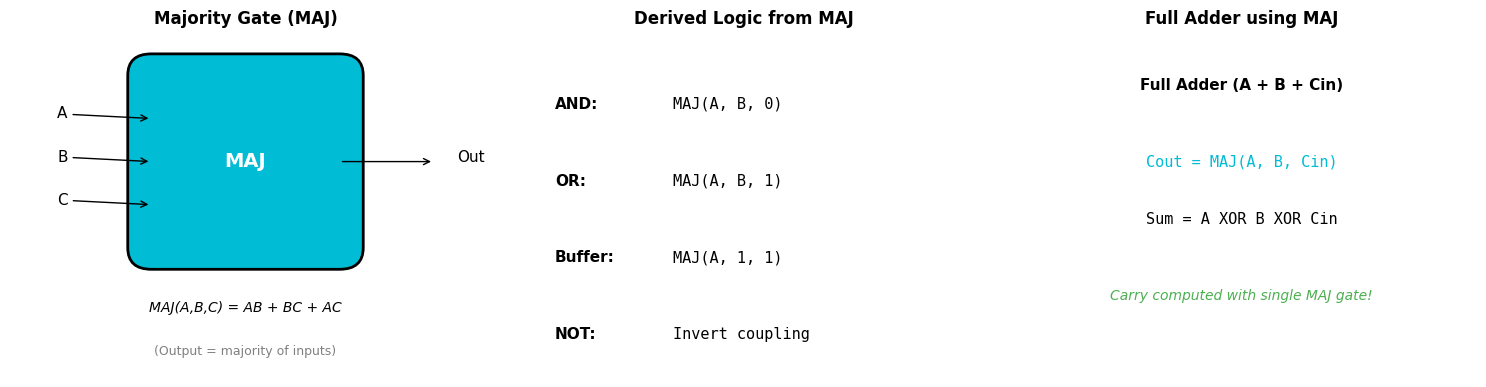

In [6]:
# Visualize: Majority gate operations
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# MAJ truth table visualization
ax = axes[0]
ax.set_title('Majority Gate (MAJ)', fontsize=12, fontweight='bold')
ax.axis('off')

# Draw MAJ gate symbol
gate = FancyBboxPatch((0.3, 0.3), 0.4, 0.4, boxstyle="round,pad=0.05",
                       facecolor=COLORS['superconducting'], edgecolor='black', linewidth=2)
ax.add_patch(gate)
ax.text(0.5, 0.5, 'MAJ', fontsize=14, ha='center', va='center', fontweight='bold', color='white')

# Inputs
ax.annotate('A', xy=(0.3, 0.6), xytext=(0.1, 0.6), fontsize=11,
           arrowprops=dict(arrowstyle='->', color='black'))
ax.annotate('B', xy=(0.3, 0.5), xytext=(0.1, 0.5), fontsize=11,
           arrowprops=dict(arrowstyle='->', color='black'))
ax.annotate('C', xy=(0.3, 0.4), xytext=(0.1, 0.4), fontsize=11,
           arrowprops=dict(arrowstyle='->', color='black'))

# Output
ax.annotate('', xy=(0.9, 0.5), xytext=(0.7, 0.5),
           arrowprops=dict(arrowstyle='->', color='black'))
ax.text(0.95, 0.5, 'Out', fontsize=11)

# Truth table below
ax.text(0.5, 0.15, 'MAJ(A,B,C) = AB + BC + AC', fontsize=10, ha='center', style='italic')
ax.text(0.5, 0.05, '(Output = majority of inputs)', fontsize=9, ha='center', color='gray')

ax.set_xlim(0, 1)
ax.set_ylim(0, 0.8)

# Derived gates
ax = axes[1]
ax.set_title('Derived Logic from MAJ', fontsize=12, fontweight='bold')
ax.axis('off')

derived = [
    ('AND', 'MAJ(A, B, 0)', 0.7),
    ('OR', 'MAJ(A, B, 1)', 0.5),
    ('Buffer', 'MAJ(A, 1, 1)', 0.3),
    ('NOT', 'Invert coupling', 0.1),
]

for gate_name, impl, y in derived:
    ax.text(0.1, y, f'{gate_name}:', fontsize=11, fontweight='bold')
    ax.text(0.35, y, impl, fontsize=11, family='monospace')

ax.set_xlim(0, 1)
ax.set_ylim(0, 0.9)

# Full adder from MAJ
ax = axes[2]
ax.set_title('Full Adder using MAJ', fontsize=12, fontweight='bold')
ax.axis('off')

# Show adder structure
ax.text(0.5, 0.75, 'Full Adder (A + B + Cin)', fontsize=11, ha='center', fontweight='bold')
ax.text(0.5, 0.55, 'Cout = MAJ(A, B, Cin)', fontsize=11, ha='center', family='monospace',
       color=COLORS['superconducting'])
ax.text(0.5, 0.40, 'Sum = A XOR B XOR Cin', fontsize=11, ha='center', family='monospace')

ax.text(0.5, 0.2, 'Carry computed with single MAJ gate!', fontsize=10, ha='center',
       style='italic', color=COLORS['success'])

ax.set_xlim(0, 1)
ax.set_ylim(0, 0.9)

plt.tight_layout()
plt.show()

### Systolic Arrays: Natural Fit for AQFP

**Systolic arrays** are a natural match for AQFP architecture:

- **Internal pipelining**: Each PE contains ~100 phases of internal pipeline
- **PE-to-PE dataflow**: PEs connected in a pipeline to avoid caches/memory
- **Regular structure**: Repeated processing elements (PEs) in a grid
- **Local connectivity**: Each PE communicates only with neighbors
- **High utilization**: Data flows continuously through the array

The key insight: pipelining happens *within* each PE (many phases), while PEs are also chained together to enable direct dataflow without memory bottlenecks.

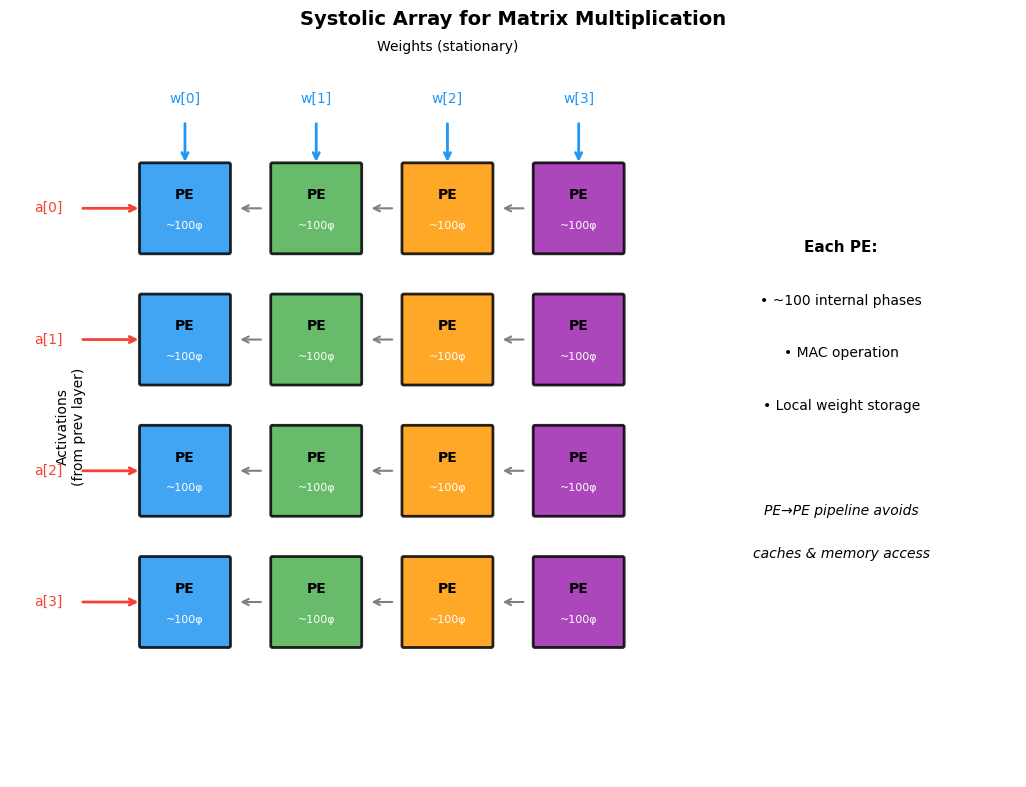

Each PE has ~100 phases of internal pipeline.
PEs connected in dataflow pipeline to avoid memory bottlenecks.


In [7]:
# Visualize: Systolic array for matrix multiplication
fig, ax = plt.subplots(figsize=(12, 8))
ax.set_title('Systolic Array for Matrix Multiplication', fontsize=14, fontweight='bold')

# Draw 4x4 PE grid
pe_size = 1.0
spacing = 1.5
grid_size = 4

# Colors for visual variety
pe_colors = [COLORS['primary'], COLORS['success'], COLORS['secondary'], COLORS['purple']]

for i in range(grid_size):
    for j in range(grid_size):
        x = 1 + j * spacing
        y = (grid_size - 1 - i) * spacing + 1
        
        # Color by column for visual clarity
        color = pe_colors[j % len(pe_colors)]
        
        rect = FancyBboxPatch((x, y), pe_size, pe_size, boxstyle="round,pad=0.02",
                              facecolor=color, edgecolor='black', linewidth=2, alpha=0.85)
        ax.add_patch(rect)
        ax.text(x + pe_size/2, y + pe_size/2 + 0.15, 'PE', fontsize=10, ha='center', 
               va='center', fontweight='bold')
        ax.text(x + pe_size/2, y + pe_size/2 - 0.2, '~100\u03c6', fontsize=8, ha='center', 
               va='center', color='white')
        
        # Arrows showing dataflow between PEs
        if j < grid_size - 1:
            ax.annotate('', xy=(x + pe_size + 0.1, y + pe_size/2), 
                       xytext=(x + pe_size + spacing - pe_size - 0.1, y + pe_size/2),
                       arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))

# Input arrows
for i in range(grid_size):
    y = (grid_size - 1 - i) * spacing + 1 + pe_size/2
    ax.annotate('', xy=(1, y), xytext=(0.3, y),
               arrowprops=dict(arrowstyle='->', color=COLORS['danger'], lw=2))
    ax.text(0.1, y, f'a[{i}]', fontsize=10, ha='right', va='center', color=COLORS['danger'])

# Weight arrows (top)
for j in range(grid_size):
    x = 1 + j * spacing + pe_size/2
    ax.annotate('', xy=(x, grid_size * spacing + 0.5), xytext=(x, grid_size * spacing + 1.0),
               arrowprops=dict(arrowstyle='->', color=COLORS['primary'], lw=2))
    ax.text(x, grid_size * spacing + 1.2, f'w[{j}]', fontsize=10, ha='center', color=COLORS['primary'])

# Labels
ax.text(0.2, grid_size * spacing / 2 + 0.5, 'Activations\n(from prev layer)', 
       fontsize=10, va='center', ha='center', rotation=90)
ax.text(grid_size * spacing / 2 + 1.5, grid_size * spacing + 1.8, 'Weights (stationary)', 
       fontsize=10, ha='center')

# Annotation box
ax.text(9, 5.5, 'Each PE:', fontsize=11, ha='center', fontweight='bold')
ax.text(9, 4.9, '\u2022 ~100 internal phases', fontsize=10, ha='center')
ax.text(9, 4.3, '\u2022 MAC operation', fontsize=10, ha='center')
ax.text(9, 3.7, '\u2022 Local weight storage', fontsize=10, ha='center')

ax.text(9, 2.5, 'PE\u2192PE pipeline avoids', fontsize=10, ha='center', style='italic')
ax.text(9, 2.0, 'caches & memory access', fontsize=10, ha='center', style='italic')

ax.set_xlim(-0.5, 11)
ax.set_ylim(-0.5, 8)
ax.set_aspect('equal')
ax.axis('off')

plt.tight_layout()
plt.show()

print("Each PE has ~100 phases of internal pipeline.")
print("PEs connected in dataflow pipeline to avoid memory bottlenecks.")

---
<a id="4-memory"></a>
# 4. Memory Architecture Challenge
---

**LLM inference has two distinct phases with different computational characteristics:**

| Phase | Description | Bottleneck |
|-------|-------------|------------|
| **Prefill** | Process input prompt (many tokens in parallel) | Compute-bound |
| **Decode** | Generate output tokens (one at a time) | Memory-bound |

**Prefill** involves large batched matrix multiplications with high arithmetic intensity — the GPU is fully utilized doing compute.

**Decode** is fundamentally memory-bound: each generated token requires loading the full model weights, but only performs ~2 FLOPs per weight loaded. The GPU is starved waiting for data.

For interactive applications (chatbots, coding assistants), decode dominates latency. This memory-bound phase is the key challenge for superconducting AI accelerators.

### The Memory Wall

Modern AI models have billions of parameters:

| Model | Parameters | Memory (FP16) |
|-------|------------|---------------|
| BERT-base | 110M | 220 MB |
| GPT-2 | 1.5B | 3 GB |
| GPT-3 | 175B | 350 GB |
| GPT-4 | ~1T (est.) | ~2 TB |

All these weights must flow through the compute units during inference.

### SCE Memory Options

| Memory Type | Capacity | Speed | Notes |
|-------------|----------|-------|-------|
| **Pipeline latches** | ~1 kbit/PE | Fastest | Native within logic (~100 phases × data width) |
| **SR loops** | ~kbits | Fast | Shift register storage, native SCE |
| **SFQ delay lines** | ~kbits | Fast | Flux storage in transmission lines |
| **Cryo-DRAM** | ~GB | Medium | Standard DRAM at 4K or 77K |
| **Room-temp DRAM** | ~TB | Slower | High bandwidth via optical links |

**Key insight**: There's no good intermediate "cache" technology in SCE. The architecture should be designed to stream data directly through the pipeline, minimizing the need for large on-chip storage.

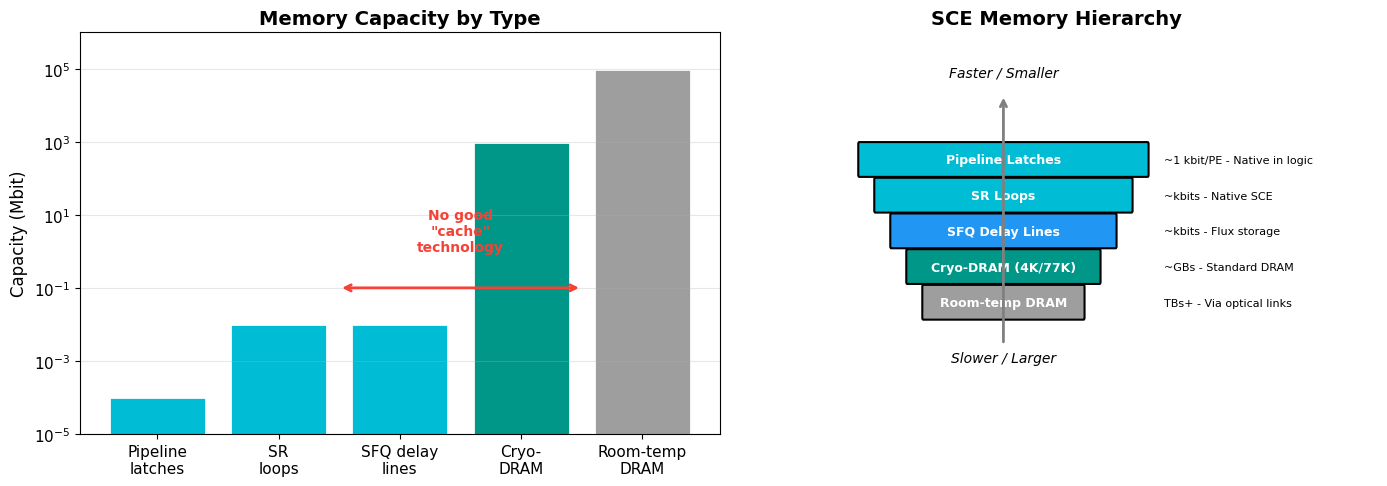

Key insight: No good intermediate cache technology in SCE.
Design should stream data directly through pipeline.


In [8]:
# Visualize: Memory hierarchy for SCE
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: Memory capacity by type
mem_types = ['Pipeline\nlatches', 'SR\nloops', 'SFQ delay\nlines', 'Cryo-\nDRAM', 'Room-temp\nDRAM']
capacities = [0.0001, 0.01, 0.01, 1000, 100000]  # Mbit equivalent
colors = [COLORS['superconducting'], COLORS['superconducting'], COLORS['superconducting'], 
          COLORS['teal'], COLORS['normal']]

bars = ax1.bar(mem_types, capacities, color=colors, edgecolor='white', linewidth=2)
ax1.set_ylabel('Capacity (Mbit)', fontsize=12)
ax1.set_title('Memory Capacity by Type', fontsize=14, fontweight='bold')
ax1.set_yscale('log')
ax1.set_ylim(0.00001, 1000000)
ax1.grid(True, alpha=0.3, axis='y')

# Annotate the gap
ax1.annotate('No good\n"cache"\ntechnology', xy=(2.5, 1), fontsize=10, ha='center',
            color=COLORS['danger'], fontweight='bold')
ax1.annotate('', xy=(1.5, 0.1), xytext=(3.5, 0.1),
            arrowprops=dict(arrowstyle='<->', color=COLORS['danger'], lw=2))

# Right: Memory hierarchy diagram  
ax2.set_title('SCE Memory Hierarchy', fontsize=14, fontweight='bold')
ax2.axis('off')

# Pyramid-style hierarchy
levels = [
    ('Pipeline Latches', '~1 kbit/PE', 'Native in logic', COLORS['superconducting'], 0.6),
    ('SR Loops', '~kbits', 'Native SCE', COLORS['superconducting'], 1.0),
    ('SFQ Delay Lines', '~kbits', 'Flux storage', COLORS['primary'], 1.4),
    ('Cryo-DRAM (4K/77K)', '~GBs', 'Standard DRAM', COLORS['teal'], 1.8),
    ('Room-temp DRAM', 'TBs+', 'Via optical links', COLORS['normal'], 2.2),
]

for name, size, note, color, y_offset in levels:
    width = 3 + (2.2 - y_offset) * 1.5  # Wider at bottom
    x = 5 - width/2
    rect = FancyBboxPatch((x, 4 - y_offset), width, 0.35, boxstyle="round,pad=0.02",
                          facecolor=color, edgecolor='black', linewidth=1.5)
    ax2.add_patch(rect)
    ax2.text(5, 4 - y_offset + 0.17, f'{name}', fontsize=9, ha='center', 
            va='center', fontweight='bold', color='white')
    ax2.text(8, 4 - y_offset + 0.17, f'{size} - {note}', fontsize=8, ha='left', va='center')

ax2.text(5, 4.5, 'Faster / Smaller', fontsize=10, ha='center', style='italic')
ax2.annotate('', xy=(5, 4.3), xytext=(5, 1.5),
            arrowprops=dict(arrowstyle='->', color='gray', lw=2))
ax2.text(5, 1.3, 'Slower / Larger', fontsize=10, ha='center', style='italic')

ax2.set_xlim(0, 12)
ax2.set_ylim(0.5, 5)

plt.tight_layout()
plt.show()

print("Key insight: No good intermediate cache technology in SCE.")
print("Design should stream data directly through pipeline.")

### Why External DRAM is Necessary

**SCE has no dense on-chip memory technology:**

- GPT-3 (175B params) at INT8 = 175 GB
- SR loops and delay lines provide ~kbits, not GB
- There's a ~6 order of magnitude gap to bridge

**Solution: Stream from DRAM**

The architecture must be designed to:
- Stream weights directly through the compute pipeline
- Use cryo-DRAM (at 4K or 77K) for lower latency
- Or room-temp DRAM via high-bandwidth optical links
- Minimize the need for on-chip "cache" since it doesn't exist

The key interface challenge is **rate matching** between fast AQFP compute and slower DRAM access.

### Optical Weight Loading: The Solution

The key insight is that **optical interconnects can deliver TB/s bandwidth to 4K with negligible heat load**. This solves the memory bandwidth challenge.

#### Zero-Bias PIN Photodiode Receivers

PIN photodiodes can operate at 4K in **photovoltaic mode** (zero bias):

- The built-in electric field (~0.5-0.7 V) sweeps photo-generated carriers without external bias
- At zero bias, **V × I electrical dissipation = 0**
- Transit-time-limited bandwidth of 5-10 GHz is achievable with 1-2 µm intrinsic layers
- Photocurrent directly drives AQFP input transformers (20-50 µA threshold)

#### Heat Sources at 4K

| Source | Heat per Channel | 1 TB/s Total | Notes |
|--------|------------------|--------------|-------|
| **Optical absorption** | 5-10 µW | 8-16 mW | 10-20% of P_opt (dominant) |
| **Fiber conduction** | ~300 nW | 0.12 mW | Fibers clamped at 40K |
| **Electrical (V × I)** | 0 | 0 | Zero bias operation |
| **Dark current** | ~0 | ~0 | Negligible at 4K |
| **Total** | — | **8-16 mW** | <1% of cryocooler capacity |

#### Energy Efficiency Comparison

| Receiver Architecture | Energy per Bit | Notes |
|----------------------|----------------|-------|
| Conventional TIA | 500-1500 fJ/bit | Active amplification |
| Cryo-CMOS front-end | 500-800 fJ/bit | Best reported |
| **Zero-bias PIN direct-drive** | **1-2 fJ/bit** | Absorption heat only |

**The zero-bias PIN approach is 500-1000× more efficient than any active receiver.**

#### System Parameters for 1 TB/s

| Parameter | Value |
|-----------|-------|
| Channel data rate | 5 Gbps NRZ |
| Channels required | 1600 |
| Fibers (4λ CWDM) | 400 |
| Optical power per channel | ~50 µW |
| Zero-bias responsivity | 0.8 A/W |
| Photocurrent | ~40 µA (above AQFP threshold) |
| Total 4K heat load | 8-16 mW |
| Fraction of 2W cryocooler | 0.4-0.8% |

<div style="background: #d4edda; border: 1px solid #28a745; border-radius: 8px; padding: 15px; margin: 15px 0;">
<strong>Key Result:</strong> A 1 TB/s optical memory link consumes only 8-16 mW at 4K — under 1% of available cooling capacity. The optical interconnect is essentially <strong>thermally free</strong>.
</div>

#### Architecture

```
┌─────────────────────────────────────────────────────────────────────┐
│  Room Temperature (300K)                                            │
│  ┌─────────────┐     ┌─────────────┐     ┌─────────────┐           │
│  │    DRAM     │────▶│   VCSELs    │────▶│  4λ CWDM    │──────┐    │
│  │  (weights)  │     │  (drivers)  │     │    Mux      │      │    │
│  └─────────────┘     └─────────────┘     └─────────────┘      │    │
└───────────────────────────────────────────────────────────────│────┘
                                                                │ Fiber
┌───────────────────────────────────────────────────────────────│────┐
│  40K Stage (fiber clamp)                                      │    │
└───────────────────────────────────────────────────────────────│────┘
                                                                │
┌───────────────────────────────────────────────────────────────│────┐
│  4K Stage                                                     ▼    │
│  ┌─────────────┐     ┌─────────────┐     ┌─────────────┐           │
│  │  4λ CWDM    │────▶│  Zero-bias  │────▶│    AQFP     │           │
│  │   Demux     │     │  PIN diodes │     │  Processor  │           │
│  └─────────────┘     └─────────────┘     └─────────────┘           │
│                       (no TIA needed)                               │
└─────────────────────────────────────────────────────────────────────┘
```

**Critical advantage**: No TIA, no bias supply, no active amplification at 4K. The photodiode photocurrent directly drives the AQFP input transformer.

---
<a id="5-system-architecture"></a>
# 5. System Architecture
---

A complete superconducting AI accelerator requires careful system-level design.

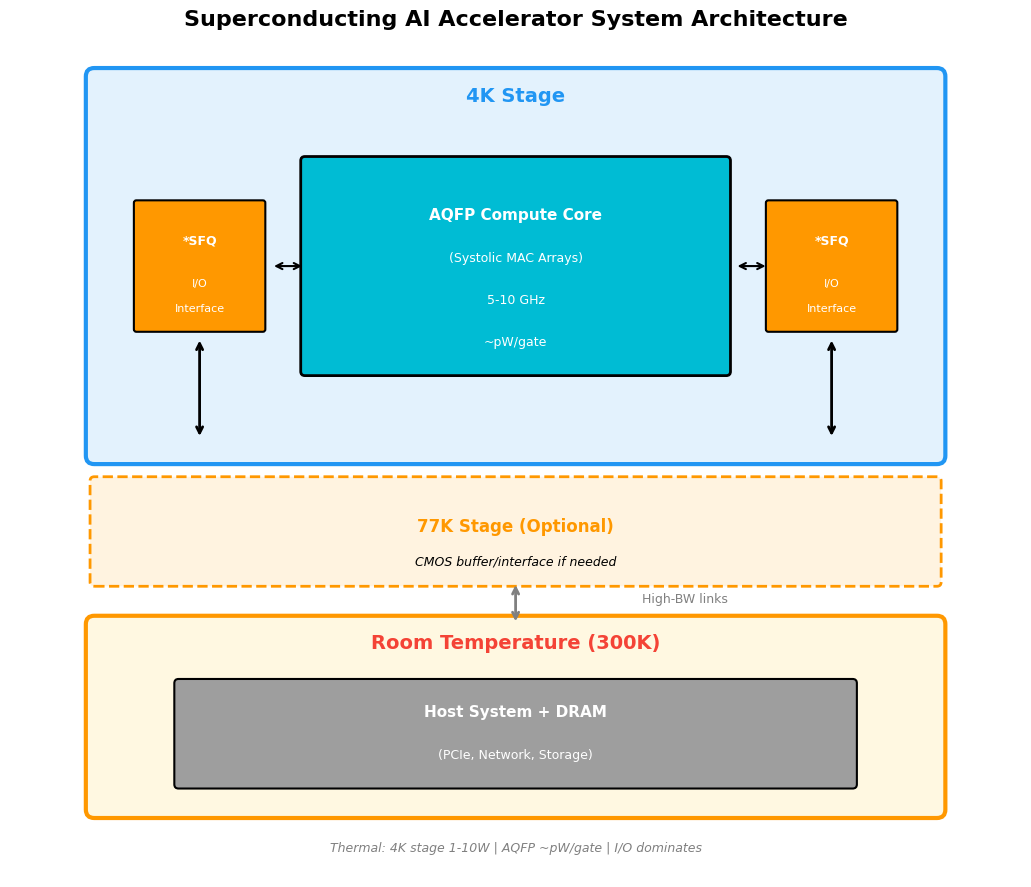

Architecture is still evolving - no cryo-CMOS at 4K.
*SFQ interfaces directly with room-temp DRAM.


In [9]:
# Visualize: Complete system architecture
fig, ax = plt.subplots(figsize=(12, 9))
ax.set_title('Superconducting AI Accelerator System Architecture', fontsize=16, fontweight='bold')

# 4K Stage box
stage_4k = FancyBboxPatch((1, 5), 10, 4.5, boxstyle="round,pad=0.1",
                          facecolor='#E3F2FD', edgecolor=COLORS['primary'], linewidth=3)
ax.add_patch(stage_4k)
ax.text(6, 9.2, '4K Stage', fontsize=14, fontweight='bold', ha='center', color=COLORS['primary'])

# AQFP Compute Core
compute_core = FancyBboxPatch((3.5, 6), 5, 2.5, boxstyle="round,pad=0.05",
                              facecolor=COLORS['superconducting'], edgecolor='black', linewidth=2)
ax.add_patch(compute_core)
ax.text(6, 7.8, 'AQFP Compute Core', fontsize=11, fontweight='bold', ha='center', color='white')
ax.text(6, 7.3, '(Systolic MAC Arrays)', fontsize=9, ha='center', color='white')
ax.text(6, 6.8, '5-10 GHz', fontsize=9, ha='center', color='white')
ax.text(6, 6.3, '~pW/gate', fontsize=9, ha='center', color='white')

# *SFQ I/O interfaces
fifo_left = FancyBboxPatch((1.5, 6.5), 1.5, 1.5, boxstyle="round,pad=0.03",
                            facecolor=COLORS['secondary'], edgecolor='black', linewidth=1.5)
ax.add_patch(fifo_left)
ax.text(2.25, 7.5, '*SFQ', fontsize=9, fontweight='bold', ha='center', color='white')
ax.text(2.25, 7.0, 'I/O', fontsize=8, ha='center', color='white')
ax.text(2.25, 6.7, 'Interface', fontsize=8, ha='center', color='white')

fifo_right = FancyBboxPatch((9, 6.5), 1.5, 1.5, boxstyle="round,pad=0.03",
                            facecolor=COLORS['secondary'], edgecolor='black', linewidth=1.5)
ax.add_patch(fifo_right)
ax.text(9.75, 7.5, '*SFQ', fontsize=9, fontweight='bold', ha='center', color='white')
ax.text(9.75, 7.0, 'I/O', fontsize=8, ha='center', color='white')
ax.text(9.75, 6.7, 'Interface', fontsize=8, ha='center', color='white')

# Data links to room temp
for x in [2.25, 9.75]:
    ax.annotate('', xy=(x, 5.2), xytext=(x, 6.4),
               arrowprops=dict(arrowstyle='<->', color='black', lw=2))

# Arrows between components
ax.annotate('', xy=(3.5, 7.25), xytext=(3.1, 7.25),
           arrowprops=dict(arrowstyle='<->', color='black', lw=1.5))
ax.annotate('', xy=(9, 7.25), xytext=(8.6, 7.25),
           arrowprops=dict(arrowstyle='<->', color='black', lw=1.5))

# Optional 77K stage
stage_77k = FancyBboxPatch((1, 3.5), 10, 1.2, boxstyle="round,pad=0.05",
                           facecolor='#FFF3E0', edgecolor=COLORS['secondary'], linewidth=2, linestyle='--')
ax.add_patch(stage_77k)
ax.text(6, 4.1, '77K Stage (Optional)', fontsize=12, fontweight='bold', ha='center', color=COLORS['secondary'])
ax.text(6, 3.7, 'CMOS buffer/interface if needed', fontsize=9, ha='center', style='italic')

# Room temperature
room_temp = FancyBboxPatch((1, 0.8), 10, 2.2, boxstyle="round,pad=0.1",
                           facecolor='#FFF8E1', edgecolor=COLORS['secondary'], linewidth=3)
ax.add_patch(room_temp)
ax.text(6, 2.7, 'Room Temperature (300K)', fontsize=14, fontweight='bold', ha='center', 
       color=COLORS['danger'])

# Host system
host = FancyBboxPatch((2, 1.1), 8, 1.2, boxstyle="round,pad=0.05",
                      facecolor=COLORS['normal'], edgecolor='black', linewidth=1.5)
ax.add_patch(host)
ax.text(6, 1.9, 'Host System + DRAM', fontsize=11, fontweight='bold', ha='center', color='white')
ax.text(6, 1.4, '(PCIe, Network, Storage)', fontsize=9, ha='center', color='white')

# Links between stages
ax.annotate('', xy=(6, 3.5), xytext=(6, 3.0),
           arrowprops=dict(arrowstyle='<->', color='gray', lw=2))
ax.text(7.5, 3.25, 'High-BW links', fontsize=9, ha='left', color='gray')

# Thermal budget annotation (inside figure area)
ax.text(6, 0.3, 'Thermal: 4K stage 1-10W | AQFP ~pW/gate | I/O dominates', 
       fontsize=9, ha='center', style='italic', color='gray')

ax.set_xlim(0, 12)
ax.set_ylim(0, 10)
ax.set_aspect('equal')
ax.axis('off')

plt.tight_layout()
plt.show()

print("Architecture is still evolving - no cryo-CMOS at 4K.")
print("*SFQ interfaces directly with room-temp DRAM.")

### Architecture Components

| Component | Technology | Function |
|-----------|------------|----------|
| **Compute core** | AQFP | Systolic MAC arrays for matrix multiplication |
| **I/O interfaces** | *SFQ async FIFOs | Clock domain crossing, rate matching |
| **Memory interface** | *SFQ | Direct interface to room-temp DRAM |
| **Data links** | Optical | High bandwidth with minimal heat leak |
| **Control** | Cryo-CMOS | Sequencing, address generation |

### Thermal Budget Considerations

At 4K, cooling capacity is limited (typically 1-10 W for practical cryocoolers):

| Source | Power | Notes |
|--------|-------|-------|
| AQFP compute | ~µW | ~pW/gate x 10^6 gates |
| *SFQ I/O | ~10s mW | Higher power but limited count |
| Cryo-CMOS | ~100s mW | Main consumer |
| Optical links | ~100s mW | At 4K side |
| Heat leak | ~W | Cryostat design dependent |

**I/O and memory interface dominate the thermal budget**, not compute.

---
<a id="6-current-research"></a>
# 6. Current Research
---

Significant research efforts are underway to realize superconducting AI accelerators.

### Major Programs

| Program | Funding | Focus | Status |
|---------|---------|-------|--------|
| **NSF DISCoVER** | $15M | Superconducting computing expedition | Active (2021-2026) |
| **IARPA C3** | Classified | Cryogenic computing complexity | Completed |
| **NIST SCE** | Internal | Superconducting neural networks | Ongoing |
| **DOE initiatives** | Various | Exascale/quantum integration | Active |

### NSF DISCoVER Expedition

The **Design and Integration of Superconducting Computation for Ventures beyond Exascale Realization (DISCoVER)** project is a $15M, 5-year NSF Expedition:

- Multi-university collaboration
- Full-stack approach: devices to architecture to applications
- Goal: Demonstrate practical superconducting computing systems
- Focus on AQFP and hybrid architectures

### Demonstrated Results

Recent publications have demonstrated practical superconducting neural networks:

| Project | Achievement | Year |
|---------|-------------|------|
| **SuperSNN** | 86% MNIST accuracy at 3 GHz | 2022 |
| **NIST ternary** | 96% MNIST with ternary weights | 2023 |
| **AQFP CNN** | Complete convolutional layer demo | 2023 |
| **Hybrid memory** | Cryo-CMOS interface demonstrated | 2022 |

### SuperSNN: Spiking Neural Networks in SCE

SuperSNN demonstrated:
- Spiking neural network implementation
- 86% accuracy on MNIST digit classification
- Operating at **3 GHz**
- Energy: ~fJ per synaptic operation

### Ternary Weight Networks

NIST researchers demonstrated:
- **96% MNIST accuracy** with ternary weights (+1, 0, -1)
- Dramatically simplified hardware
- Weights stored as flux quanta

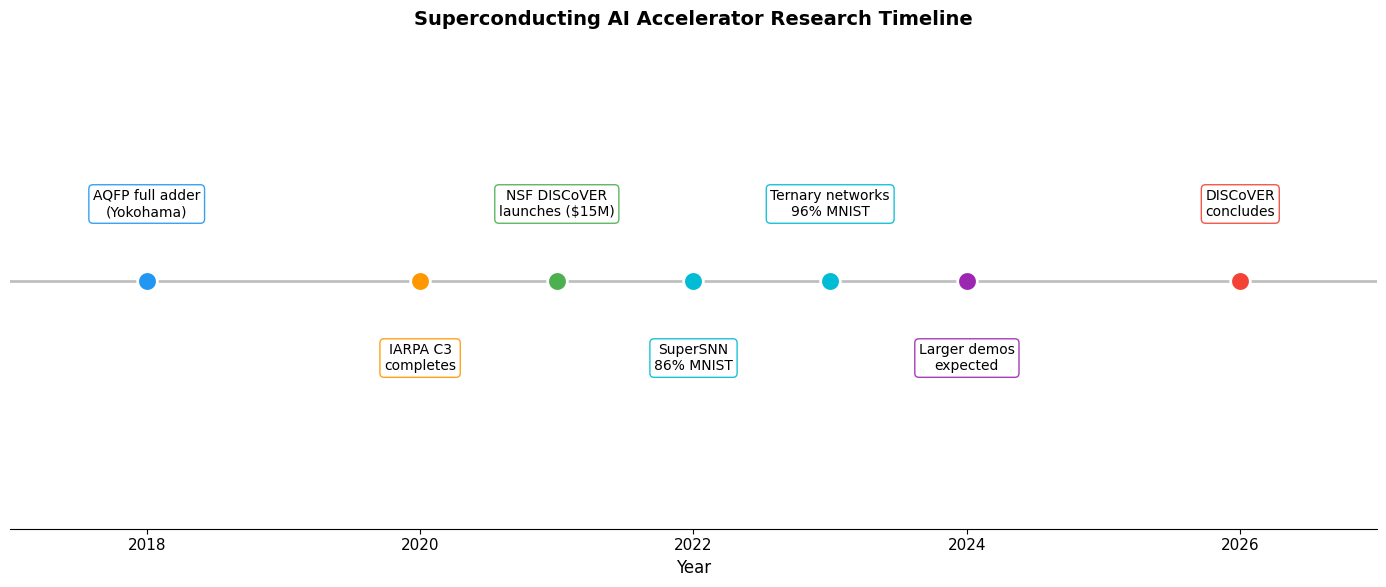

The field is rapidly advancing with demonstrated results.


In [10]:
# Visualize: Research progress timeline
fig, ax = plt.subplots(figsize=(14, 6))

# Timeline
milestones = [
    (2018, 'AQFP full adder\n(Yokohama)', COLORS['primary']),
    (2020, 'IARPA C3\ncompletes', COLORS['secondary']),
    (2021, 'NSF DISCoVER\nlaunches ($15M)', COLORS['success']),
    (2022, 'SuperSNN\n86% MNIST', COLORS['superconducting']),
    (2023, 'Ternary networks\n96% MNIST', COLORS['superconducting']),
    (2024, 'Larger demos\nexpected', COLORS['purple']),
    (2026, 'DISCoVER\nconcludes', COLORS['danger']),
]

# Draw timeline
ax.axhline(y=0.5, color='gray', linewidth=2, alpha=0.5)

for i, (year, label, color) in enumerate(milestones):
    # Marker
    ax.scatter(year, 0.5, s=200, color=color, zorder=5, edgecolor='white', linewidth=2)
    
    # Label (alternate above/below)
    y_offset = 0.2 if i % 2 == 0 else -0.2
    va = 'bottom' if i % 2 == 0 else 'top'
    ax.text(year, 0.5 + y_offset, label, fontsize=10, ha='center', va=va,
           bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=color, alpha=0.9))

ax.set_xlim(2017, 2027)
ax.set_ylim(-0.3, 1.3)
ax.set_xlabel('Year', fontsize=12)
ax.set_title('Superconducting AI Accelerator Research Timeline', fontsize=14, fontweight='bold')
ax.set_yticks([])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.tight_layout()
plt.show()

print("The field is rapidly advancing with demonstrated results.")

---
<a id="7-quantized-networks"></a>
# 7. Quantized Networks
---

**Quantized neural networks** are particularly well-suited for superconducting implementation.

### Why Quantization Matters for SCE

Lower precision means:
- **Fewer gates** per operation
- **Smaller multipliers** (or elimination entirely)
- **Better fit** for current integration density (~10K gates)

### Ternary Weights: Ideal for SCE

**Ternary weights (+1, 0, -1)** are particularly elegant:

| Weight | Meaning | Implementation |
|--------|---------|----------------|
| +1 | Add activation | Pass through |
| 0 | Ignore | No connection |
| -1 | Subtract activation | Invert and add |

**No multiplication needed!** Just addition, subtraction, and routing.

### Binary Neural Networks

For maximum simplicity, **binary networks** use only +1/-1:

```
Output = popcount(XNOR(inputs, weights)) - threshold
```

This reduces to:
- XNOR gates (can be built from MAJ)
- Population count (sum of 1s)
- Comparison

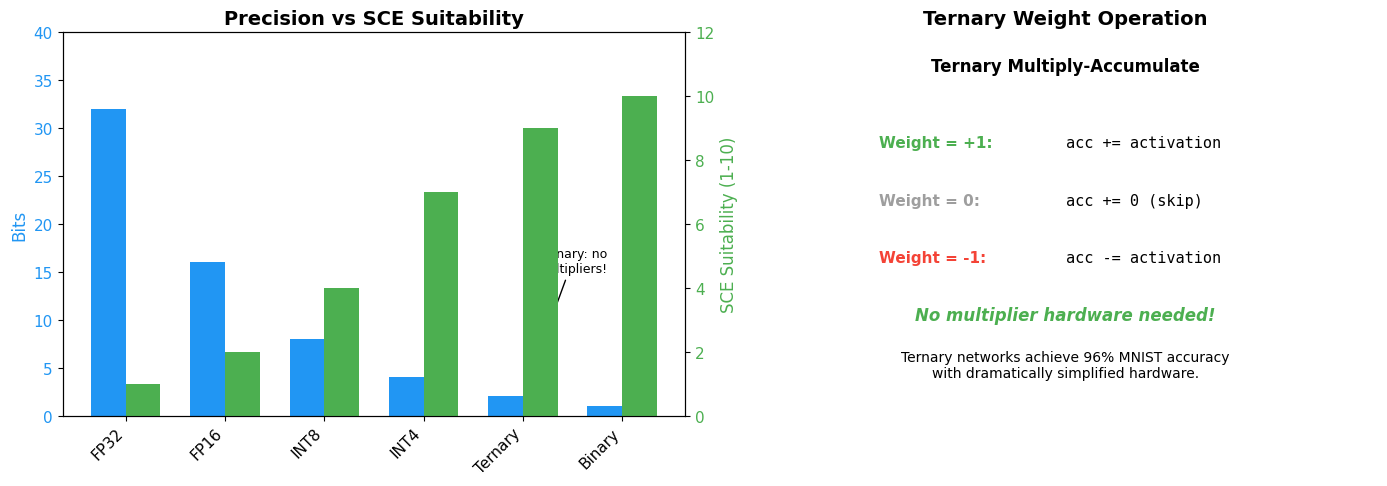

In [11]:
# Visualize: Quantization levels and accuracy trade-offs
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: Precision vs complexity
precisions = ['FP32', 'FP16', 'INT8', 'INT4', 'Ternary', 'Binary']
bits = [32, 16, 8, 4, 2, 1]
mult_complexity = [1024, 256, 64, 16, 0, 0]  # Relative multiplier complexity
accuracy_loss = [0, 0.1, 0.5, 2, 3, 8]  # Typical accuracy loss (%)
sce_fit = [1, 2, 4, 7, 9, 10]  # Suitability for SCE (1-10)

x = np.arange(len(precisions))
width = 0.35

bars1 = ax1.bar(x - width/2, bits, width, label='Bits per weight', color=COLORS['primary'])
ax1.set_ylabel('Bits', fontsize=12, color=COLORS['primary'])
ax1.tick_params(axis='y', labelcolor=COLORS['primary'])

ax1_twin = ax1.twinx()
bars2 = ax1_twin.bar(x + width/2, sce_fit, width, label='SCE suitability', color=COLORS['success'])
ax1_twin.set_ylabel('SCE Suitability (1-10)', fontsize=12, color=COLORS['success'])
ax1_twin.tick_params(axis='y', labelcolor=COLORS['success'])
ax1_twin.set_ylim(0, 12)

ax1.set_xticks(x)
ax1.set_xticklabels(precisions, rotation=45, ha='right')
ax1.set_title('Precision vs SCE Suitability', fontsize=14, fontweight='bold')
ax1.set_ylim(0, 40)

# Annotations
ax1.annotate('Ternary: no\nmultipliers!', xy=(4, 2), xytext=(4.5, 15),
            fontsize=9, ha='center',
            arrowprops=dict(arrowstyle='->', color='black'))

# Right: Ternary weight implementation
ax2.set_title('Ternary Weight Operation', fontsize=14, fontweight='bold')
ax2.axis('off')

# Show ternary MAC
ax2.text(0.5, 0.9, 'Ternary Multiply-Accumulate', fontsize=12, fontweight='bold',
        ha='center', transform=ax2.transAxes)

operations = [
    ('Weight = +1:', 'acc += activation', COLORS['success']),
    ('Weight = 0:', 'acc += 0 (skip)', COLORS['normal']),
    ('Weight = -1:', 'acc -= activation', COLORS['danger']),
]

for i, (weight, op, color) in enumerate(operations):
    y = 0.7 - i * 0.15
    ax2.text(0.2, y, weight, fontsize=11, fontweight='bold', color=color,
            transform=ax2.transAxes)
    ax2.text(0.5, y, op, fontsize=11, family='monospace',
            transform=ax2.transAxes)

ax2.text(0.5, 0.25, 'No multiplier hardware needed!', fontsize=12,
        ha='center', transform=ax2.transAxes, color=COLORS['success'],
        fontweight='bold', style='italic')

ax2.text(0.5, 0.1, 'Ternary networks achieve 96% MNIST accuracy\n'
        'with dramatically simplified hardware.', fontsize=10,
        ha='center', transform=ax2.transAxes)

plt.tight_layout()
plt.show()

### TAB-TNN: Optimized Ternary Networks

**TAB-TNN (Ternary Arithmetic Binary-coded Ternary Neural Networks)** optimizes ternary operations:

- **Bit-packing**: Multiple ternary weights packed together
- **2.3x speedup** through efficient encoding
- Maintains accuracy while reducing hardware complexity

### Accuracy vs Efficiency Trade-off

| Precision | ImageNet Accuracy | Relative Efficiency |
|-----------|------------------|--------------------|
| FP32 | 76% (baseline) | 1x |
| INT8 | 75.5% | 4x |
| INT4 | 74% | 8x |
| Ternary | 70% | 100x+ |
| Binary | 58% | 1000x+ |

For many practical applications, the accuracy loss is acceptable given the enormous efficiency gains.

---
<a id="8-challenges"></a>
# 8. Challenges and Path Forward
---

Significant challenges remain before superconducting AI accelerators become practical.

### Current Challenges

| Challenge | Current State | Target | Approach |
|-----------|--------------|--------|----------|
| **Integration density** | ~10K gates | ~100M gates | Multi-chip modules, 3D integration |
| **Memory bandwidth** | Limited by I/O | >TB/s | Cryo-CMOS integration, optical links |
| **I/O power** | Dominates budget | <100 mW | Efficient level converters |
| **Design tools** | Academic/custom | Production-ready | EDA company involvement |
| **Fabrication** | Few fabs | Multiple sources | Industry investment |

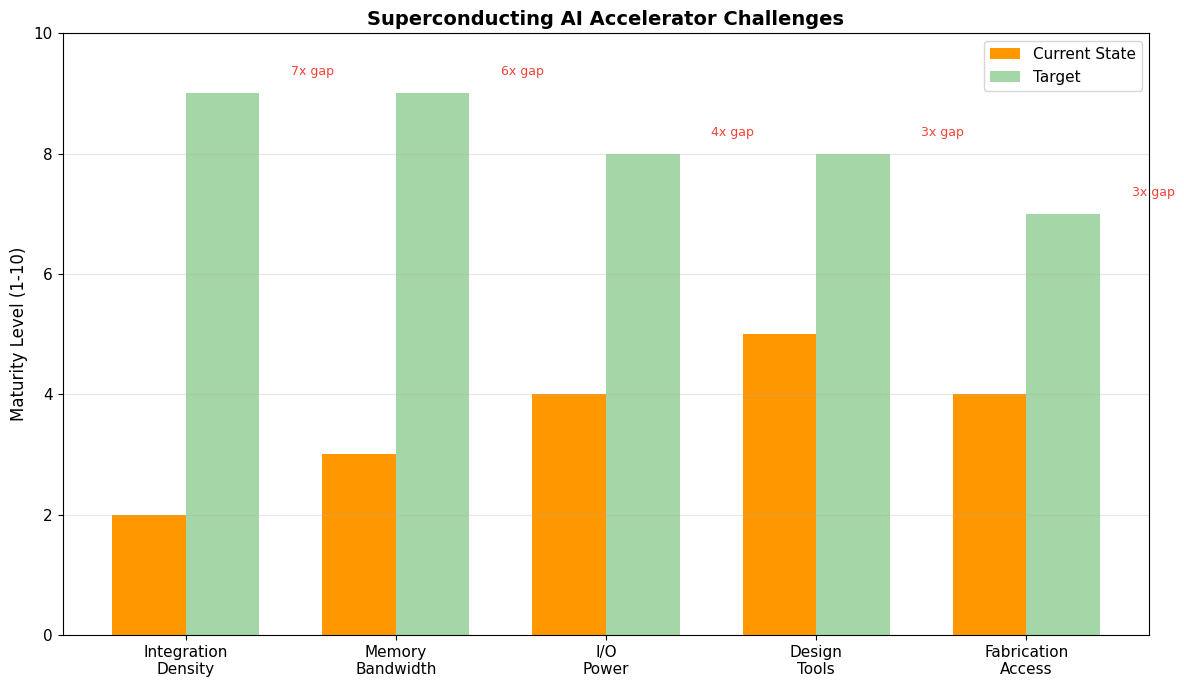

Integration density is the largest gap - requires ~10,000x improvement.


In [12]:
# Visualize: Challenges and progress
fig, ax = plt.subplots(figsize=(12, 7))

challenges = ['Integration\nDensity', 'Memory\nBandwidth', 'I/O\nPower', 
              'Design\nTools', 'Fabrication\nAccess']
current = [2, 3, 4, 5, 4]  # 1-10 scale of maturity
target = [9, 9, 8, 8, 7]

x = np.arange(len(challenges))
width = 0.35

bars1 = ax.bar(x - width/2, current, width, label='Current State', color=COLORS['secondary'])
bars2 = ax.bar(x + width/2, target, width, label='Target', color=COLORS['success'], alpha=0.5)

ax.set_ylabel('Maturity Level (1-10)', fontsize=12)
ax.set_title('Superconducting AI Accelerator Challenges', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(challenges)
ax.legend()
ax.set_ylim(0, 10)
ax.grid(True, alpha=0.3, axis='y')

# Gap annotations
for i, (c, t) in enumerate(zip(current, target)):
    gap = t - c
    ax.annotate(f'{gap}x gap', xy=(i + width/2, t), xytext=(i + 0.5, t + 0.3),
               fontsize=9, color=COLORS['danger'])

plt.tight_layout()
plt.show()

print("Integration density is the largest gap - requires ~10,000x improvement.")

### Path Forward

#### Near-term (1-3 years)
- Demonstrate larger-scale prototypes (~100K gates)
- Validate hybrid cryo-CMOS memory integration
- Develop production-quality design tools
- Establish design methodologies

#### Medium-term (3-5 years)
- Multi-chip module integration
- ~1M gate demonstrations
- Practical inference accelerators for specific workloads
- Industry partnerships for fabrication

#### Long-term (5-10 years)
- Full-scale AI accelerator systems
- Commercial deployment for specific applications
- Integration with quantum computing systems
- Potential paradigm shift in data center computing

---
<a id="9-other-applications"></a>
# 9. Other SCE Applications
---

While this course focuses on AI acceleration, superconducting electronics has other important applications.

### Quantum Computing

Superconducting qubits are a leading approach to quantum computing:

| Component | Technology | Notes |
|-----------|------------|-------|
| **Transmon qubits** | Al/AlOx/Al JJs | Most common qubit type |
| **Readout** | Parametric amplifiers | Near quantum-limited |
| **Control** | Cryo-CMOS + SCE | Scalability challenge |

SCE control electronics at 4K could dramatically improve quantum computer scalability.

### Sensors

| Sensor Type | Application | Sensitivity |
|-------------|-------------|-------------|
| **SQUIDs** | Magnetometry | ~10^-15 T/sqrt(Hz) |
| **SNSPDs** | Single photon detection | >95% efficiency |
| **TES** | Bolometry | ~10^-18 W sensitivity |
| **KIDs** | mm-wave imaging | Array-friendly |

### Medical Imaging

| Application | Technology | Status |
|-------------|------------|--------|
| **MEG** | SQUID arrays | Clinical use |
| **MCG** | SQUID arrays | Research/clinical |
| **MRI** | HTS coils | Emerging |

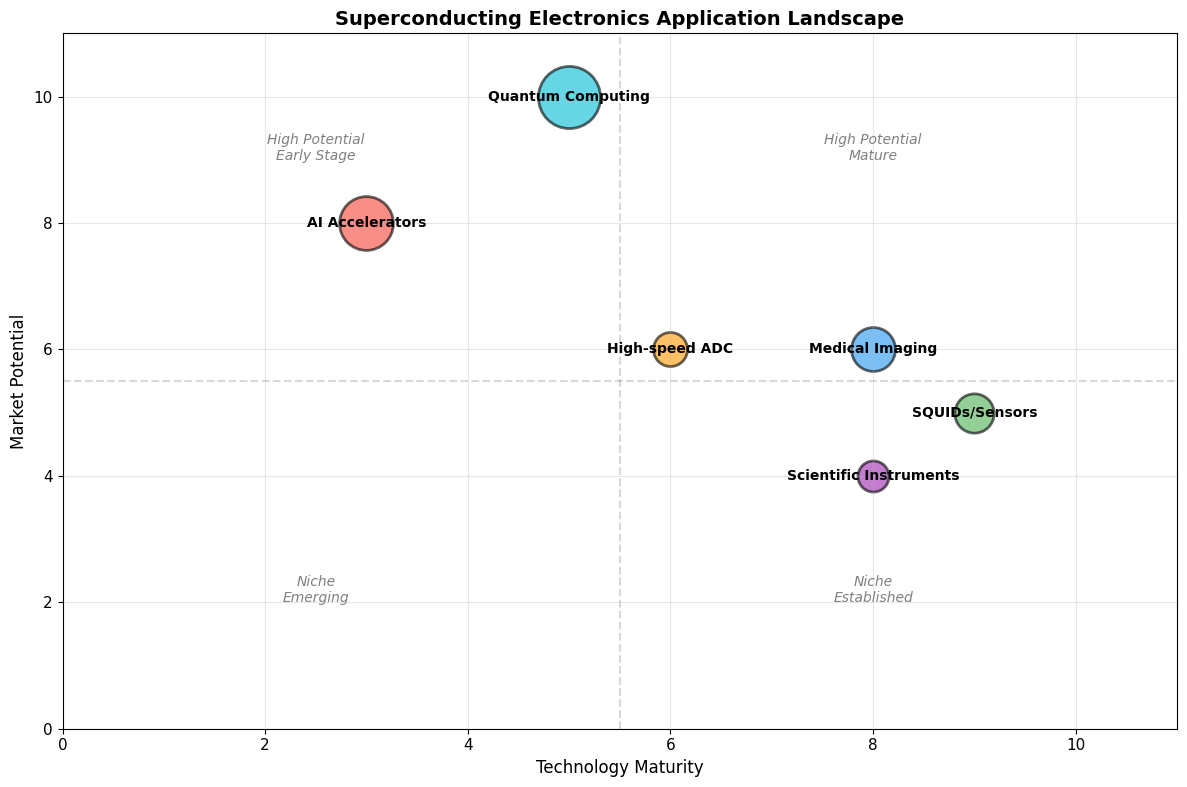

AI acceleration and quantum computing represent the largest growth opportunities.
Sensor applications provide near-term commercial opportunities.


In [13]:
# Visualize: SCE application landscape
fig, ax = plt.subplots(figsize=(12, 8))
ax.set_title('Superconducting Electronics Application Landscape', fontsize=14, fontweight='bold')

# Create bubble chart
applications = [
    ('AI Accelerators', 8, 3, 1500, COLORS['danger']),       # (name, potential, maturity, size, color)
    ('Quantum Computing', 10, 5, 2000, COLORS['superconducting']),
    ('SQUIDs/Sensors', 5, 9, 800, COLORS['success']),
    ('Medical Imaging', 6, 8, 1000, COLORS['primary']),
    ('High-speed ADC', 6, 6, 600, COLORS['secondary']),
    ('Scientific Instruments', 4, 8, 500, COLORS['purple']),
]

for name, potential, maturity, size, color in applications:
    ax.scatter(maturity, potential, s=size, c=color, alpha=0.6, edgecolors='black', linewidth=2)
    ax.annotate(name, (maturity, potential), fontsize=10, ha='center', va='center',
               fontweight='bold')

ax.set_xlabel('Technology Maturity', fontsize=12)
ax.set_ylabel('Market Potential', fontsize=12)
ax.set_xlim(0, 11)
ax.set_ylim(0, 11)
ax.grid(True, alpha=0.3)

# Quadrant labels
ax.text(2.5, 9, 'High Potential\nEarly Stage', fontsize=10, ha='center', 
       style='italic', color='gray')
ax.text(8, 9, 'High Potential\nMature', fontsize=10, ha='center', 
       style='italic', color='gray')
ax.text(2.5, 2, 'Niche\nEmerging', fontsize=10, ha='center', 
       style='italic', color='gray')
ax.text(8, 2, 'Niche\nEstablished', fontsize=10, ha='center', 
       style='italic', color='gray')

# Reference lines
ax.axvline(x=5.5, color='gray', linestyle='--', alpha=0.3)
ax.axhline(y=5.5, color='gray', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

print("AI acceleration and quantum computing represent the largest growth opportunities.")
print("Sensor applications provide near-term commercial opportunities.")

### Synergies with Quantum Computing

Superconducting AI accelerators share infrastructure with quantum computers:

- **Same cryogenic systems**: 4K cooling already deployed
- **Same fabrication**: Nb trilayer process
- **Complementary**: Classical control for quantum systems
- **Co-location**: AI inference next to quantum processors

This creates opportunities for **hybrid quantum-classical systems** with superconducting classical compute at cryogenic temperatures.

---
<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 100%); color: white; padding: 30px; margin: 20px -10px -10px -10px; border-radius: 15px 15px 0 0; text-align: center;">

## Summary

### The AI Compute Challenge
- Training compute doubling every ~6 months (4x per year)
- Largest datacenters today are already at **1+ GW** scale
- This is **unsustainable** with conventional technology

### Why Superconducting Logic?
- AQFP: ~1.4 zJ per operation vs ~13,000 aJ for CMOS 7nm
- Even with 1000x cooling overhead: **~80x net advantage**
- Clock speeds of 5-10 GHz compensate for density

### Key Architecture Elements
- **AQFP** systolic arrays for compute
- **Optical interconnect** for weight streaming from room-temp DRAM
- **Zero-bias PIN photodiodes** — no TIA, no active amplification at 4K
- ***SFQ** async FIFOs at I/O boundaries

### Optical Weight Loading
- **1 TB/s bandwidth** with only **8-16 mW** heat at 4K
- **1-2 fJ/bit** receiver energy (500-1000× better than TIA)
- Optical interconnect is essentially **thermally free** (<1% of cooling budget)

### Current State
- Demonstrated: 96% MNIST accuracy with ternary weights
- Active research: NSF DISCoVER ($15M), NIST, multiple universities
- Challenges: Integration density (~10K gates), optical-to-AQFP interface

### Key Numbers
| Parameter | Value |
|-----------|-------|
| AQFP energy | ~1.4 zJ/op |
| Net efficiency gain | ~80× vs CMOS |
| Clock frequency | 5-10 GHz |
| Optical receiver energy | 1-2 fJ/bit |
| 1 TB/s optical heat load | 8-16 mW |
| Cooling overhead | ~1000 W at 300K per W at 4K |

---

### Course Complete!

You now have foundational knowledge in superconductor electronics with a focus on AQFP-based AI acceleration. The field is at an exciting inflection point, with growing research investment and demonstrated results pointing toward practical systems.

**The path to sustainable AI compute may run through liquid helium.**

</div>